In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from huggingface_hub import hf_hub_download
from pathlib import Path
import torch
import albumentations as A
import matplotlib.pyplot as plt
from src.model.SaTformer.SaTformer import SaTformer
from src.model.SaTformerPixelClassifier import SaTformerPixelClassifier
from src.dm import DataModule


# SaTformer

In [21]:

hf_hub_download(repo_id="leharris3/satformer", filename="sf-64-cls.pt", local_dir="weights")

'/home/juan/Desktop/competis/PrecipitationNowcasting/weights/sf-64-cls.pt'

In [ ]:
model = SaTformer(
    dim=512,
    num_frames=4,       # number HRIT input frames
    num_classes=64,     # number precipitation bins to use
    image_size=32,      # HRIT input spatial dimensions
    patch_size=4,
    channels=11,        # number HRIT radiance channels
    depth=12,           # number transformer encoder blocks
    heads=8,
    dim_head=64,
    attn_dropout=0.1,
    ff_dropout=0.1,
    rotary_emb=False,   # i.e., use postitional embeds
    attn="ST^2"
)

In [27]:
weights_path = Path('weights/sf-64-cls.pt')
state_dict = torch.load(weights_path, map_location='cpu')
model.load_state_dict(state_dict, strict=False)
model.eval();

In [28]:
with torch.no_grad():
    inputs = torch.rand(1, 4, 11, 32, 32) # randomly generated HRIT input
    logits = model(inputs)                # call model forward pass
    print(logits.shape)                   # -> [1, 64]; raw model probs over output classes

torch.Size([1, 64])


Understanding the Dimensions & Weights
- num_frames=4: The pretrained model expects exactly 4 input frames. In your data batch, you have up to 3 frames (at $t-30$, $t-20$, and $t-10$ minutes). We will address how to handle this frame mismatch in the next steps (e.g., by zero-padding, repeating a frame, or interpolating).
- channels=11: The pretrained model expects exactly 11 channels (corresponding to the 11 SEVIRI bands). Your dataset contains 16 bands. In the next steps, we will map your 16 bands down to the 11 aligned bands to make them compatible with the pretrained weights, or adjust the model to accept 16 bands if we train from scratch.
- image_size=32: The pretrained model expects a $32 \times 32$ spatial grid. Your data input images are $41 \times 41$ (or cropped from $128 \times 128$). We will look at how to crop or resize your input to $32 \times 32$ to feed it into the model.

# Adaptation

In [ ]:

dm = DataModule(band_mapping=False)
dm.setup()

In [75]:
batch = next(iter(dm.train_dataloader()))

batch['inputs'].shape, batch['target'].shape, batch['satellite_target']

(torch.Size([1, 4, 16, 81, 81]), torch.Size([1, 41, 41]), ['himawari'])

Number of frames

In [79]:
model = SaTformer(
    dim=512,
    num_frames=4,       # funciona con 3, pero 4 usa mejor los pesos preentrenados
    num_classes=64,     # number precipitation bins to use
    image_size=32,      # HRIT input spatial dimensions
    patch_size=4,
    channels=11,        # number HRIT radiance channels
    depth=12,           # number transformer encoder blocks
    heads=8,
    dim_head=64,
    attn_dropout=0.1,
    ff_dropout=0.1,
    rotary_emb=False,   # i.e., use postitional embeds
    attn="ST^2"
)

with torch.no_grad():
    inputs = torch.rand(1, 3, 11, 32, 32) # randomly generated HRIT input
    logits = model(inputs)                # call model forward pass
    print(logits.shape)                   # -> [1, 64]; raw model probs over output classes

torch.Size([1, 64])


Input channels

The pretrained SaTformer was trained on 11 bands from the SEVIRI instrument (Meteosat) in the following order, we map our 16 bands to these 11.

In [65]:
BAND_MAPPING = {
    'himawari': [4, 6, 10, 11, 13, 14, 15, 2, 3, 7, 9],  # B05, B07, B11, B12, B14, B15, B16, B03, B04, B08, B10
    'goes':     [4, 6, 10, 11, 13, 14, 15, 1, 2, 7, 9],  # C05, C07, C11, C12, C14, C15, C16, C02, C03, C08, C10
    'meteosat': [6, 8, 11, 12, 13, 14, 15, 2, 3, 9, 10]  # nir_16, ir_38, ir_87, ir_97, ir_105, ir_123, ir_133, vis_06, vis_08, wv_63, wv_73
}

dm = DataModule(band_mapping=True)
dm.setup()

In [66]:
batch = next(iter(dm.train_dataloader()))

batch['inputs'].shape, batch['target'].shape, batch['satellite_target']

(torch.Size([1, 4, 11, 144, 144]), torch.Size([1, 41, 41]), ['meteosat'])

Input size

Need to resize inputs to 32x32

In [85]:
trans = A.Compose([
    A.Resize(32, 32)
], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

dm = DataModule(train_trans=trans, val_trans=trans)
dm.setup()
batch = next(iter(dm.train_dataloader()))

batch['inputs'].shape, batch['target'].shape, batch['satellite_target']


(torch.Size([1, 4, 11, 32, 32]), torch.Size([1, 41, 41]), ['meteosat'])

In [93]:
model = SaTformer(
    dim=512,
    num_frames=4,       
    num_classes=64,     # number precipitation bins to use
    image_size=32,      # HRIT input spatial dimensions
    patch_size=4,
    channels=11,        
    depth=12,           
    heads=8,
    dim_head=64,
    attn_dropout=0.1,
    ff_dropout=0.1,
    rotary_emb=False,   
    attn="ST^2"
)

with torch.no_grad():
    logits = model(batch['inputs'])               
    print(logits.shape)                

torch.Size([1, 64])


Output

Instead of 1x64 bin distribution, we get on for each pixel on the 41x41 output with a custom model:

- Uses the pretrained SaTformer as a spatial-temporal feature extractor to extract patch tokens.
- Reshapes those patch tokens back into a spatial-temporal grid of shape (batch, frames, dim, 8, 8).
- Collapses the temporal dimension (taking the mean across frames) to get a 2D feature map of shape (batch, 512, 8, 8).
- Passes this feature map through a convolutional decoder to output a tensor of shape (batch, 64, 41, 41) — representing 64 logits (probabilities) per pixel for each of the $41 \times 41$ pixels.
- Converts those 64 probabilities per pixel back into a single continuous precipitation rate during inference using the expected value across the bins.

In [94]:
pixel_model = SaTformerPixelClassifier(model, num_classes=64)
pixel_model.eval();

In [95]:
with torch.no_grad():
    logits = pixel_model(batch['inputs'])
    pred_continuous = pixel_model.predict_regression(batch['inputs'])

print(f"Input batch shape:         {batch['inputs'].shape}")
print(f"Output logits shape:        {logits.shape} (64 bins per pixel)")
print(f"Output regression shape:    {pred_continuous.shape} (Matches target shape: {batch['target'].shape})")
print(f"Min predicted rain rate:    {pred_continuous.min().item():.4f}")
print(f"Max predicted rain rate:    {pred_continuous.max().item():.4f}")

Input batch shape:         torch.Size([1, 4, 11, 32, 32])
Output logits shape:        torch.Size([1, 64, 41, 41]) (64 bins per pixel)
Output regression shape:    torch.Size([1, 41, 41]) (Matches target shape: torch.Size([1, 41, 41]))
Min predicted rain rate:    0.4995
Max predicted rain rate:    0.5040


# Data Augmentation

In [3]:
trans = A.Compose([
    A.Resize(32, 32)
], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

trans = None

dm = DataModule(train_trans=trans, val_trans=trans)
dm.setup()
batch = next(iter(dm.train_dataloader()))

batch['inputs'].shape, batch['target'].shape, batch['satellite_target']

(torch.Size([1, 3, 11, 81, 81]), torch.Size([1, 41, 41]), ['himawari'])

In [4]:
def plot_batch(dl, samples=1):
    for i in range(samples):
        batch = next(iter(dl))
        fig, axs = plt.subplots(1, 4, figsize=(15, 5))
        for i in range(3):
            axs[i].imshow(batch['inputs'][0, i, 0])
            axs[i].set_title(f'Shape: {batch["inputs"][0, i, 0].shape}')
            axs[i].axis('off')
        axs[3].imshow(batch['target'][0])
        axs[3].set_title(f'Shape: {batch["target"][0].shape}')
        axs[3].axis('off')
        plt.tight_layout()
        plt.show()

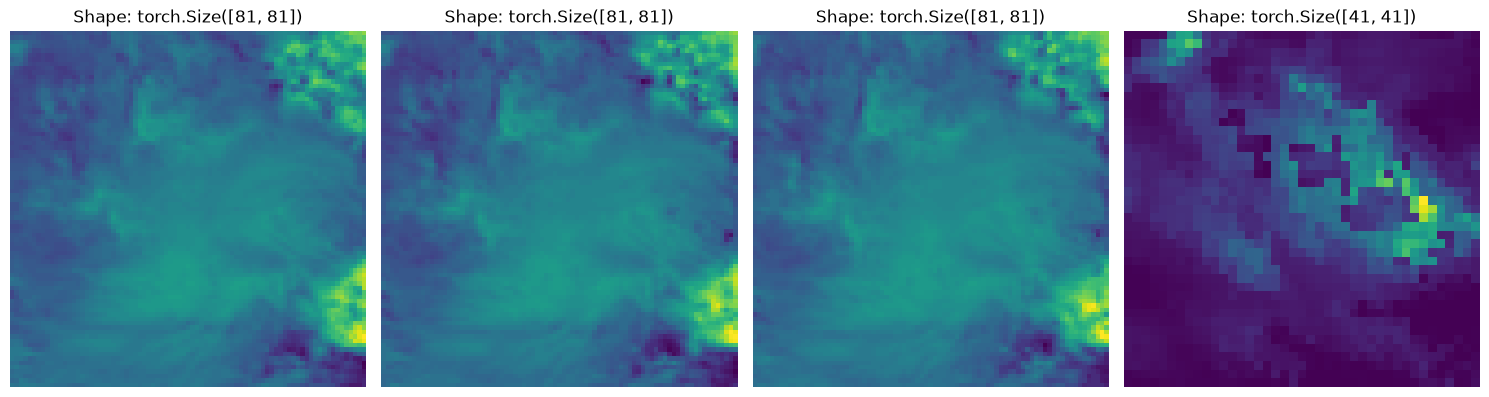

In [5]:
plot_batch(dm.train_dataloader(shuffle=False))

In [6]:
trans = A.Compose([
    A.Resize(32, 32),
], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

trans2 = A.ReplayCompose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
], is_check_shapes=False, additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

dm = DataModule(train_trans=trans, val_trans=trans, train_trans2=trans2)
dm.setup()

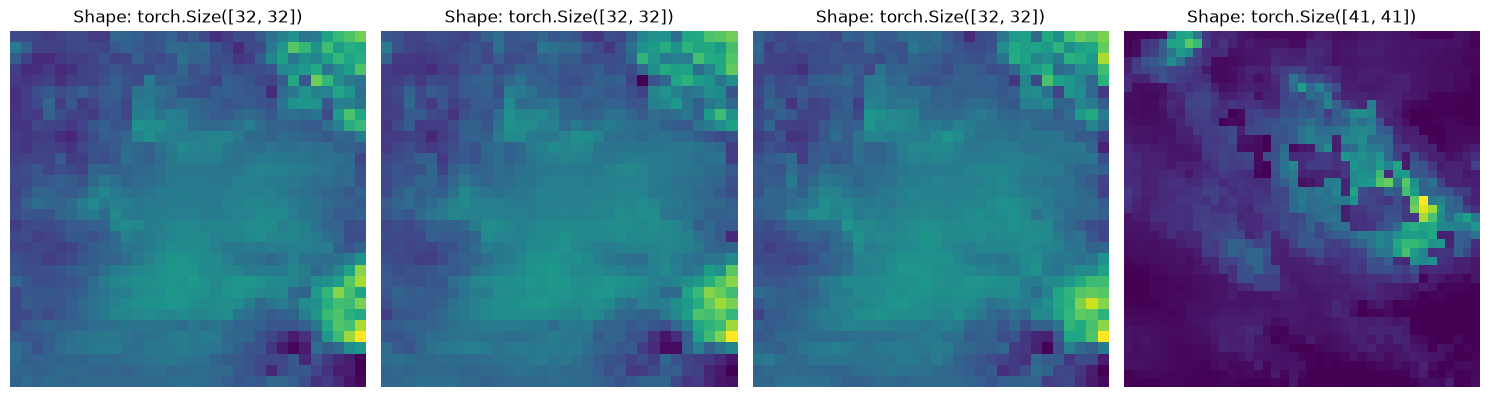

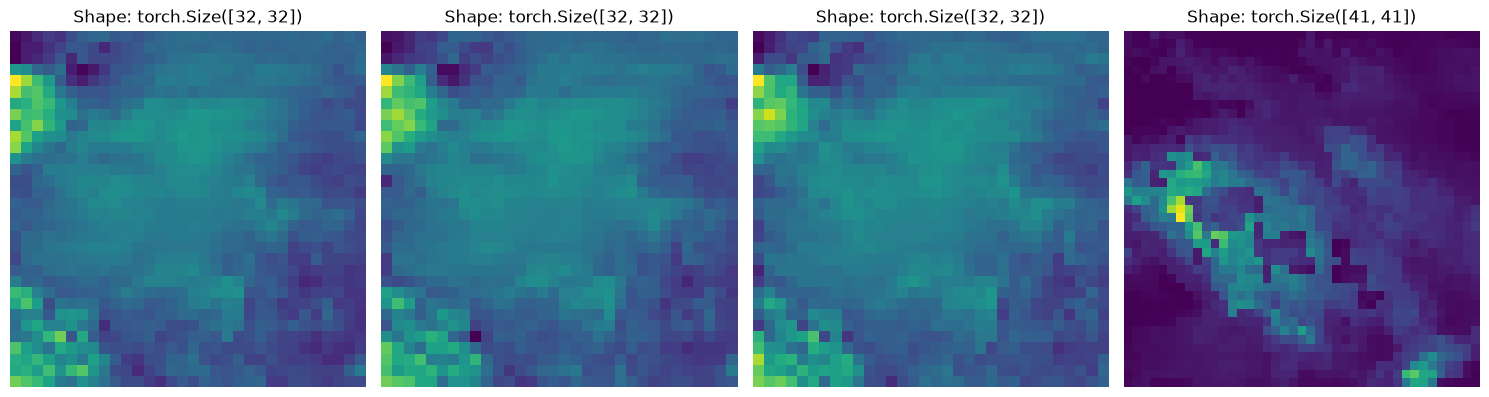

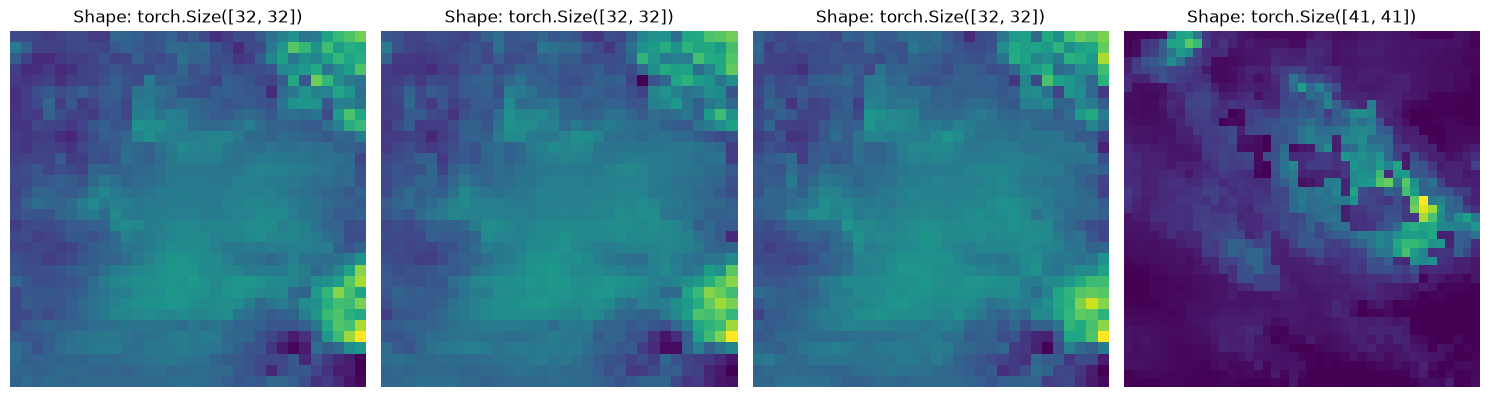

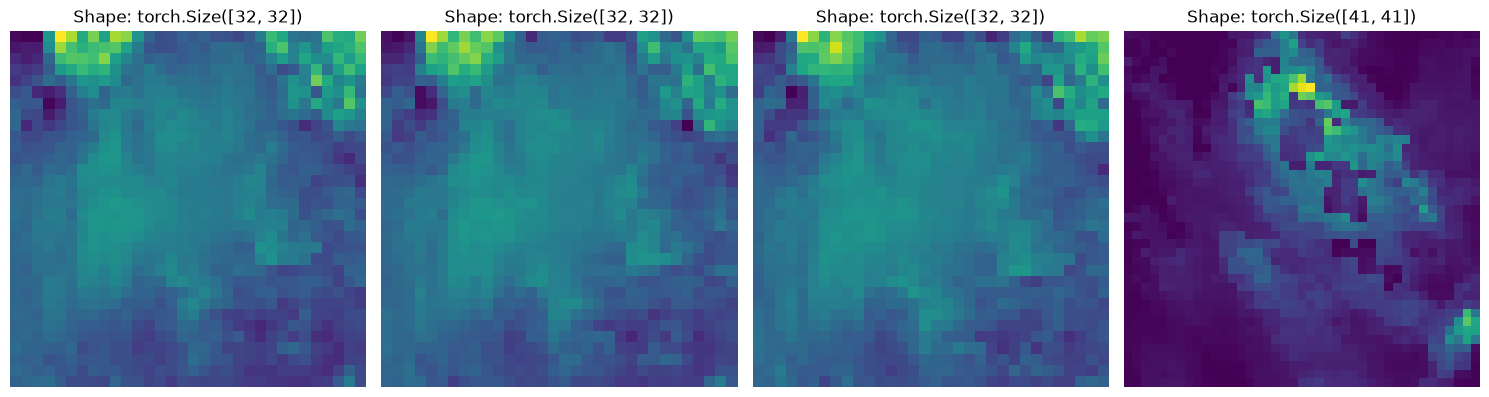

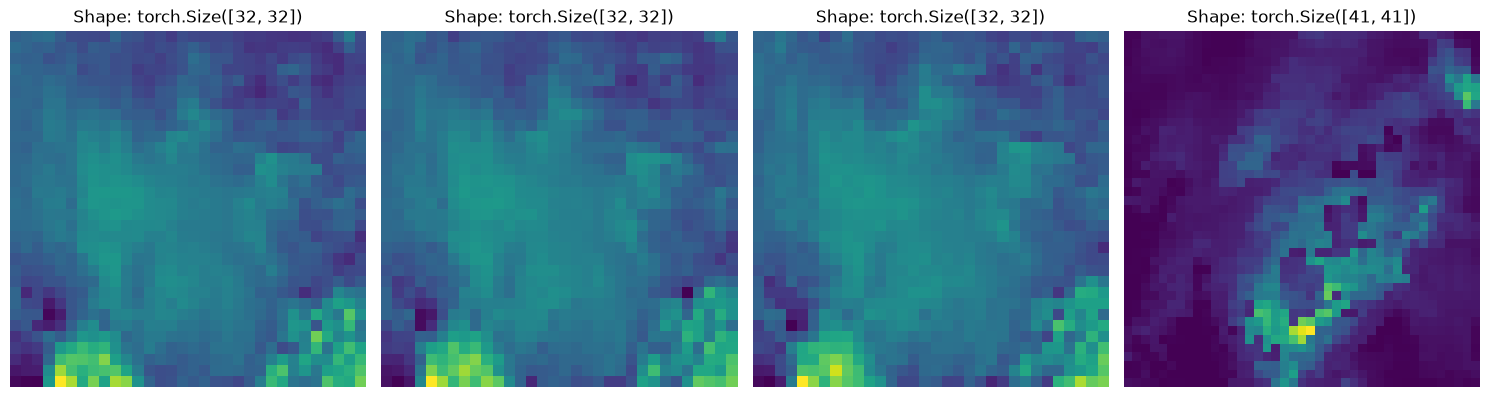

In [7]:
plot_batch(dm.train_dataloader(shuffle=False), 5)

In [8]:
trans = A.Compose([
    A.Resize(41, 41),
], additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

trans2 = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.RandomResizedCrop((32, 32)),
], is_check_shapes=False, additional_targets={'image1': 'image', 'image2': 'image', 'image3': 'image'})

dm = DataModule(train_trans=trans, val_trans=trans, train_trans2=trans2, resize_target=True)
dm.setup()

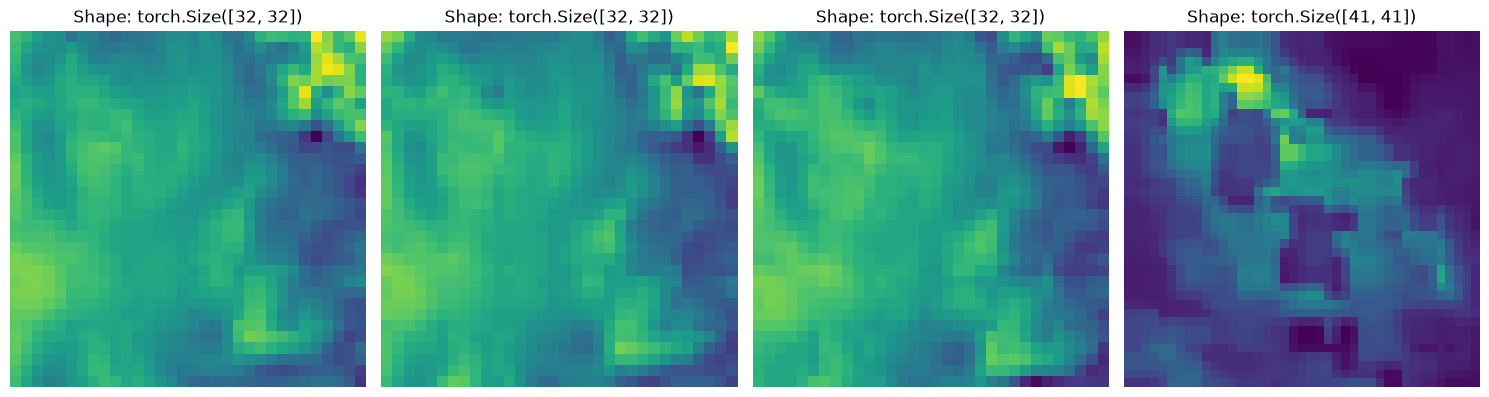

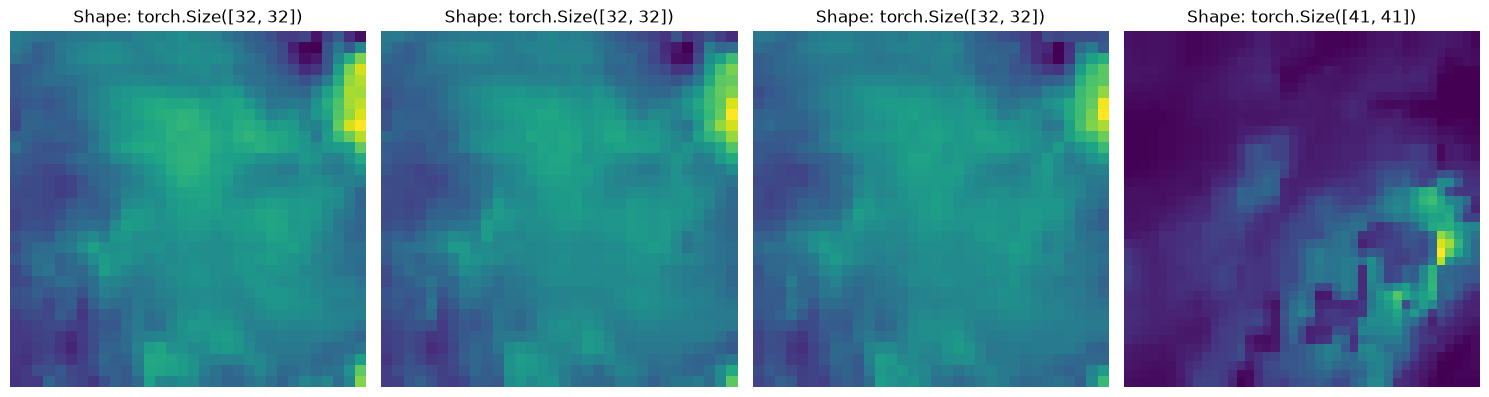

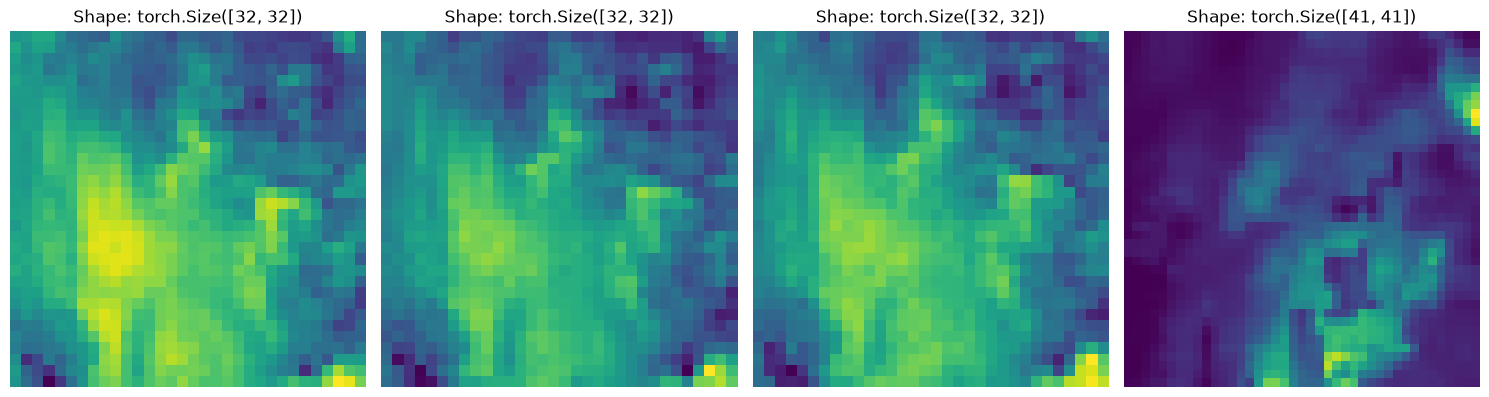

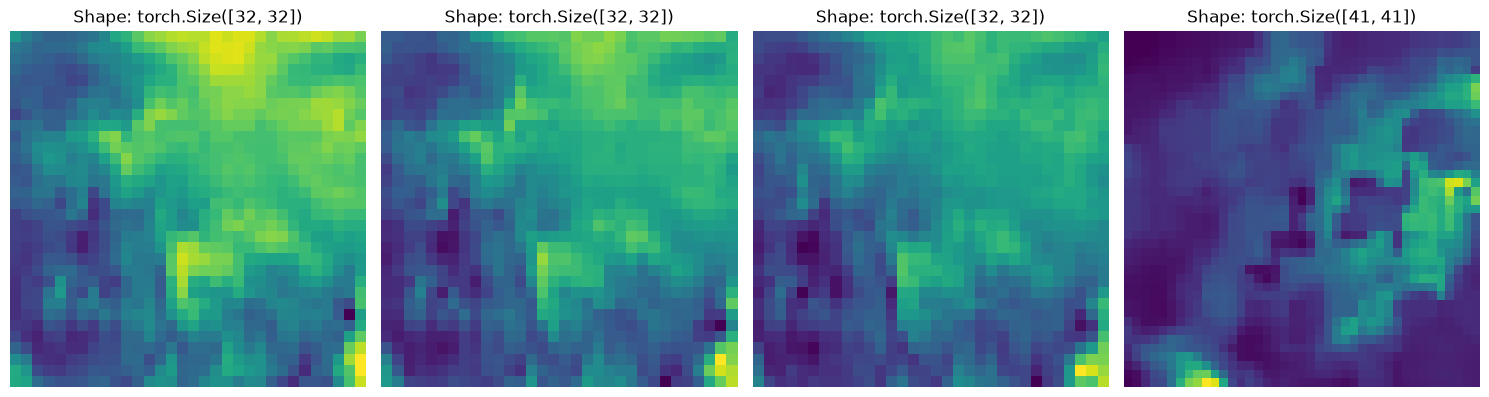

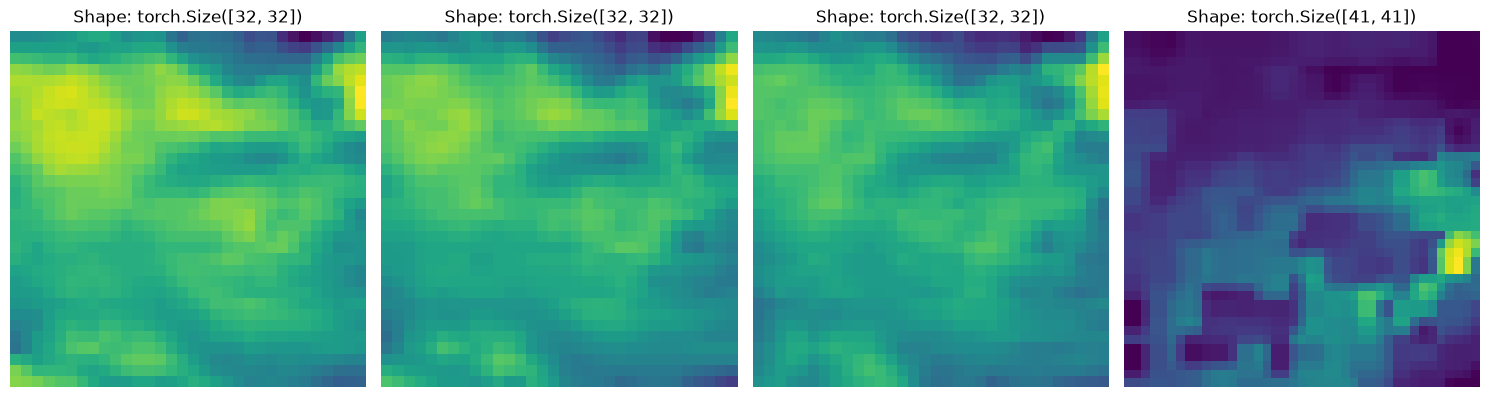

In [9]:
plot_batch(dm.train_dataloader(shuffle=False), 5)